In [46]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress 
import os

In [48]:
print(f"Running on PyTorch {torch.__version__}")

Running on PyTorch 2.5.1+cpu


In [49]:
float_dtype = torch.float32
torch_float_dtype = float_dtype

For running this notebook a GPU is recommended, code below will check if a CUDA device is available and if so select the first device on the list. For M* (Apple) and AMD Graphics cards, you have to install the appropriate  PyTorch version and consult corresponding documentation.

In [50]:
import neumc

In [51]:
if torch.cuda.is_available():
    print("Available cuda devices:")
    for dev in range(torch.cuda.device_count()):
        prop = torch.cuda.get_device_properties(dev)
        print(
            f"{prop.name}: Compute capability {prop.major}.{prop.minor} {prop.total_memory / 2 ** 30:.1f}GB Multiprocessor count {prop.multi_processor_count}")
    print()
    torch_device = 'cuda'
    print(f"Running on {torch.cuda.get_device_name(torch_device)}")
    if float_dtype == 'float64':
        print("Double precision on gaming GPUs is much slower than the single precision!");
else:
    torch_device = 'cpu'
    print(f'Running on {neumc.utils.cpuinfo.get_processor_name()} CPU')
    print("Warning you do not have a CUDA  device, running on CPU will be VERY slow!");

Running on Intel64 Family 6 Model 140 Stepping 1, GenuineIntel CPU
Warning you do not have a CUDA  device, running on CPU will be VERY slow!


# $U(1)$ lattice gauge theory

Gauge theories on the lattice are different from theories like $\phi^4$ in that respect that the variables are defined not on the lattice sites but on the links of the lattice.

$$U_\mu(\vec x)$$

 is a link variable starting from $\vec x$ in direction $\mu$. Each link variable is a member of a _gauge group_ $G$.

The action for this theory is defined as

$$S(U) = -\beta\sum_{\vec x}\sum_{\mu=0,\nu=\mu+1}^{D-1}\operatorname{Re} \operatorname{Tr}P_{\mu,\nu}(\vec x)$$

where $P_{\mu,\nu}(x)$ is the plaquette, that is the product of the links around the smallest possible loop

\begin{equation}
    P_{\mu,\nu}(\vec x)=U_\nu(\vec x) U_\mu(\vec x+\hat{\nu}) U_\nu^\dagger(\vec x+\hat{\mu}) U_\mu^\dagger (\vec x).
\end{equation}

The $\hat\mu$ is the displacement vector of one lattice site in the direction $\mu$.
The dagger indicates hermitian conjugate of the link variable that indicates that we are traversing the link in the opposite direction.

In case of two dimensions $\vec x = (x,y)$ and at each lattice site there is only one plaquette $P_{0,1}(x,y)$

\begin{equation}
    P_{0,1}(x,y)=P(x,y)=U_1(x,y) U_0(x,y+1) U_1^\dagger(x+1,y) U_0^\dagger (x,y).
\end{equation}

In [52]:
import sys

sys.path.append('..')
from mask_plots import plaquette, annotated_plaquette, link, plot_plaq_mask

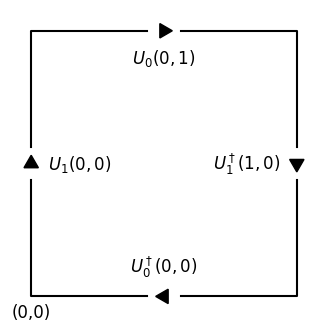

In [53]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_aspect(1)
annotated_plaquette(ax, 0, 0)
ax.axis('off');
fig.savefig("plaq.pdf")

In this notebook we are considering a very simple gauge group $U(1)$. This is a group of two-dimensional rotations. This is an Abelian group, meaning that the elements of this group commute.  The elements of this group can represented by complex numbers with unit norm

$$U_\mu(\vec x)=e^{i \phi_\mu(\vec x)}.$$ 

The $\phi_\mu(\vec x)$ variables are real valued phases, $0\le \phi_\mu(\vec x)<2\pi$, and that are the variables that we will use to represent the gauge field $U$. 

In terms of phases

$$P_{\mu,\nu}(\vec x)=
e^{i\left(
\phi_\nu(\vec x) + \phi_\mu(\vec x+\hat{\nu}) -\phi_\nu(\vec x+\hat{\mu})- \phi_\mu (\vec x).
\right)}
$$

and 

$$\operatorname{Re} P_{\mu,\nu}(\vec x)=
\cos\left(
\phi_\nu(\vec x) + \phi_\mu(\vec x+\hat{\nu}) -\phi_\nu(\vec x+\hat{\mu})- \phi_\mu (\vec x)
\right).
$$

## Partition function and free energy

The partition function is defined as 

$$Z(\beta)=\int \prod_{\vec{x}}\prod_{\mu} \text{d}U_\mu(\vec x) e^{-\beta S(U)}$$

The $\text{d} U$ is a _Haar_ measure on the $U(1)$ group and in this simple case is defined as

$$\text{d} U = \frac{1}{2\pi}\text{d}\phi.$$

For this particular model,  partition function can be calculated exactly (courtesy of R. Janik)

$$Z(\beta) = \frac{1}{\left(2\pi\right)^{2L^2}}\left(I_0(\beta)^{L^2}+2\sum_{n=1}^\infty I_n(\beta)^{L^2}\right)$$

the multiplicative factor in front stemming from the measure. The $I_n$ are the modified Bessel functions of the first kind.  The logarithm of the expression inside the parenthesis is implemented as the `logZ` function in the module `neumc.physics.u1`.   

In [54]:
import neumc
from neumc.utils import grab
import neumc.physics.u1 as u1

In [55]:
L = 8 #lattice spacing; 
beta = 1 #coupling; 
F_exact = -u1.logZ(L, beta) - 2 * L * L * np.log(2 * np.pi) 

print(F_exact)


-250.34678344485565


By default, this function does take only two  first terms of the series, but for this value of $\beta$ we do not gain anything by taking another term

In [56]:
F_exact = -u1.logZ(L, beta, n=3) - 2 * L * L * np.log(2 * np.pi)
print(F_exact)

-250.34678344485565


## Gauge symmetry

Gauge fields $U_\mu(\vec x)$ and the action $S(U)$ are so defined as to respect the _gauge_ symmetry. 

The gauge transformation is defined as follows: We first define a new set of variables $g(\vec x)\in G$  living at the sites of the lattice and then transform every link as

$$U_\mu(\vec x)\longrightarrow g(\vec x)U_\mu(\vec x)g^\dagger(\vec x+\mu)$$

This is a _local_ transformation, as each link is transformed differently based on it's neighboring $g$ fields.

If we take a product of $U$ on any closed loop on the lattice $L(\vec x)$ that starts and end in the same point $\vec x$, under the gauge transformation $g$ it will transform as

$$L(\vec x)\rightarrow g(\vec x) L(\vec x) g^\dagger(\vec x)$$

The trace of such a loop will be invariant under this transformation

$$\operatorname{Tr} g(\vec x) L(\vec x) g^\dagger(\vec x)=\operatorname{Tr} L(\vec x) g^\dagger(\vec x)g(\vec x)=
\operatorname{Tr}L(\vec x)$$

In particular, the action is invariant under the gauge transform. 

In case of an Abelian group like $U(1)$ there is no need to take a trace as all the loops are gauge invariant by themselves. 

## Implementation

As mentioned previously, we represent the fields by their phases. We store configurations as an array of shape $(N,2,L,L)$. The first dimension is the _batch_ dimension enumerating the configurations and the second dimension, that can take only values $0,1$, indicates the direction of the link. 

In [57]:
L = 8
lattice_shape = (L, L) #2D lattice, useful for dynamic coding; 
link_shape = (2, L, L) #links per site in 2D lattice (x and y directions); 
batch_size = 1024 #? 

# some arbitrary configurations
cfgs = 2 * torch.pi * torch.rand((batch_size, 2, L, L), device=torch_device, dtype=torch_float_dtype)
cfgs.shape

torch.Size([1024, 2, 8, 8])

In [58]:
beta = 1
u1_action = neumc.physics.u1.U1GaugeAction(beta)

We can perform a gauge transformation on those configurations and check if the action is really invariant. Of course, we may expect the invariance only up to numerical accuracy.

In [59]:
# action is invariant
torch.set_printoptions(precision=7)
cfgs_transformed = u1.random_gauge_transform(cfgs, device=torch_device)
act = u1_action(cfgs)
act_tr = u1_action(cfgs_transformed)
assert np.allclose(grab(u1_action(cfgs)), grab(u1_action(cfgs_transformed)), atol=1e-4), \
    'gauge transform should be a symmetry of the action'

### Rectangular $2\times 1$ loops

As already stated for $U(1)$ gauge group all the closed loops  are gauge invariant. At the same stage, we will also need the rectangular $2\times 1$ loops for additional invariants. At each   point  we can define two such loops

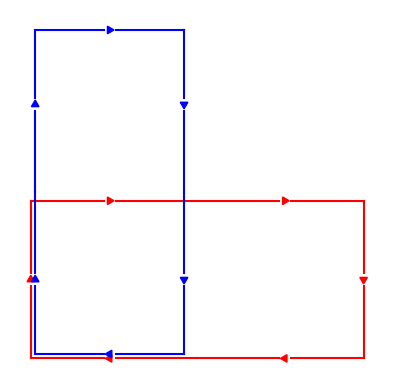

In [60]:
from mask_plots import loop, plot_plaq_mask

fig, ax = plt.subplots()
ax.set_aspect(1.0)
#
ax.axis('off')
loop(ax, 0, 0, 'urrdll', l=0.035, d=0.05, color='red')
loop(ax, 0, 0, 'uurddl', l=0.035, d=0.075, color='blue')

In [61]:
p2x1 = u1.compute_u1_2x1_loops(cfgs)
p2x1.shape

torch.Size([1024, 2, 8, 8])

In [62]:
p2x1_trasformed = u1.compute_u1_2x1_loops(cfgs_transformed)

In [63]:
assert np.allclose(grab(p2x1), grab(p2x1), 1e-6), \
    'gauge transformation must leave all loops invariant'

## Topological charge

$$Q = \frac{1}{2\pi}\sum_{\vec x}\arg P(\vec x)$$

In [64]:
Q = grab(u1.topo_charge(cfgs))
assert np.allclose(Q, np.around(Q), atol=1e-5), 'topological charge must be an integer'

## Gauge equivariance


As in the $\phi^4$ case, we will construct a normalizing flow that will transform  random variables $z$ coming from some simple distribution $q_z(z)$ into fields $u(z)$. We require function $u(z)$ to be a bijection. Then probability of configuration $u(z)$ is then given by

$$q(u(z)) = q_z(z)\left|\frac{\partial u(z)}{\partial z} \right|^{-1}$$

Gauge symmetry is a defining feature of gauge field theories. In principle, the distribution $q$ does not need to respect this symmetry. In practice, this may make training very difficult or even impossible. It would be then advantageous  to construct normalizing flows that respect this symmetry, i.e.

$$q(u(z)) = q(g(u(z)))$$

A possible way to implement such flow is to construct a _gauge equivariant_ flow which commutes with the gauge transformation $g$. 

$$g(u(z)) = u(g(z))$$

Together with gauge invariant prior  

$$q_z(g(z))=q_z(z)$$

and the fact that gauge transformation has a Jacobian equal to one, this will guarantee that the resulting distribution $q$ will be gauge invariant. 

$$\left|\frac{\partial g(u(z))}{\partial z}\right| = 
\left|\frac{\partial u(g(z))}{\partial z}\right|$$

$$\left|\frac{\partial g(u(z))}{\partial u(z)}\right|
\left|\frac{\partial u(z)}{\partial z} \right|= 
\left|\frac{\partial u(g(z))}{\partial g(z)}\right|
\left|\frac{\partial g(z)}{\partial z}\right|$$

Because Jacobian of $g$ is equal to one, we are left with 

$$
\left|\frac{\partial u(z)}{\partial z} \right|= 
\left|\frac{\partial u(g(z))}{\partial g(z)}\right|
$$

and finally

$$q(g(u(z))) = q(u(g(z)))=q_z(g(z))\left|\frac{\partial u(g(z))}{\partial g(z)}\right|^{-1}
=q_z(z)\left|\frac{\partial u(z)}{\partial z} \right|^{-1}=q(u(z))
$$

## Prior

Implementation of invariant prior is easy. We just take uniform distribution on $[0,2\pi)$ for each $z$

$$q_z(\vec z)=\frac{1}{\left(2\pi\right)^{2L^2}},\quad \log q_z(\vec z)=-2L^2\log 2\pi$$  

In [65]:
prior = neumc.nf.prior.MultivariateUniform(torch.zeros(link_shape), 2 * np.pi * torch.ones(link_shape),
                                           device=torch_device)

In [66]:
z = prior.sample_n(6)
print(f'z.shape = {z.shape}')
print(f'log r(z) = {grab(prior.log_prob(z))}')

z.shape = torch.Size([6, 2, 8, 8])
log r(z) = [-235.24828 -235.24828 -235.24828 -235.24828 -235.24828 -235.24828]


In [67]:
-2 * L * L * np.log(2 * np.pi)

-235.2482645003962

## Transformation

The tricky part is implementation of the gauge equivariant flow. We will follow the approach proposed first in [arXiv:2003.06413](https://arxiv.org/abs/2003.06413). As in the $\phi^4$ case, the flow will be constructed by stacking a number of layers. So it will be enough to assure gauge equivariance of each layer. 

The general idea behind the gauge equivariant coupling layer is to transform the plaquettes and use those transformed plaquettes to transform the links.

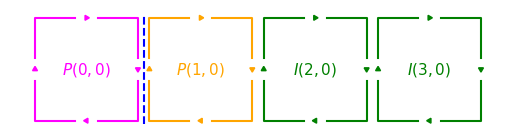

In [68]:
fig, ax = plt.subplots();
ax.set_aspect(1)
ax.axis('off')
link(ax, 1, 0, 1, color='blue', d=0.025, linestyle='--')
d = 0.05
plaquette(ax, 0, 0, color='magenta', d=d, text='$P(0,0)$');
plaquette(ax, 1, 0, color='orange', d=d, text='$P(1,0)$');
plaquette(ax, 2, 0, color='green', d=d, text='$I(2,0)$');
plaquette(ax, 3, 0, color='green', d=d, text='$I(3,0)$');

Take a look at the above picture. We would like to update link $U_1(1,0)$ marked as the dashed blue line. To this end we will first change the value of the _active_ plaquette $P(1,0)$ using the invariant quantities $I(2,0)$ and $I(3,0)$ constructed from _frozen_ plaquettes $P(2,0)$ and $P(3,0)$ (or in general all the frozen green links) 

$$P(1,0)\rightarrow h\left(P(1,0)|I(2,0), I(3,0)\right)=P'(1,0)$$

We will call function $h$ a _kernel_ or plaquettes coupling layer. 

If we assume that only link $U_1(1,0)$ changes, then

$$
P(1,0)=U_1(1,0) U_0(1,1) U_1^\dagger(2,0) U_0^\dagger (1,0)
$$
$$
P'(1,0)=U'_1(1,0) U_0(1,1) U_1^\dagger(2,0) U_0^\dagger (1,0)
$$

and

$$U'_1(1,0)=h(P(1,0)|I)) P(1,0)^\dagger U_1(1,0) $$

Of course,  after this link changes, the value of the plaquette $P(0,0)$ will also change. We will call this a _passive_ plaquette.

Under the gauge transformation, the right-hand side transforms as

$$h(g(1,0)P(1,0)g^\dagger(1,0)|I)) g(1,0)P(1,0)^\dagger g^\dagger(1,0) g(1,0)U_1(1,0)g(1,1)^\dagger
=h(g(1,0)P(1,0)g^\dagger(1,0)|I)) g(1,0)P(1,0)^\dagger U_1(1,0)g(1,1)^\dagger
$$

If we assume that 

$$h(g P q^\dagger)= g h(P)g^\dagger$$

for each $g, P\in G$ then we finally obtain

$$g(1,0)h(P(1,0)|I) P(1,0)^\dagger U_1(1,0)g(1,1)^\dagger = g(1,0)U'_1(1,0)g^\dagger(1,1)$$

which is the needed result.

For Abelian  groups like $U(1)$  the required property is satisfied for any kernel $h$ as  $g P g^\dagger=P$. 

This pattern is repeated across the whole lattice 

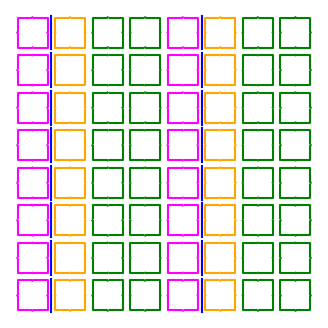

In [69]:
masks_gen = neumc.nf.gauge_masks.u1_masks_gen(lattice_shape=(8, 8), float_dtype=float_dtype, device='cpu')
masks = [next(masks_gen) for i in range(8)]
fig, ax = plt.subplots(figsize=(4, 4))
plot_plaq_mask(ax, masks[3]);

and all blue links are updated conditioned on the invariant build out of the green plaquettes. This updates only one eight of the links, and we need to repeat this process using different masking patterns 

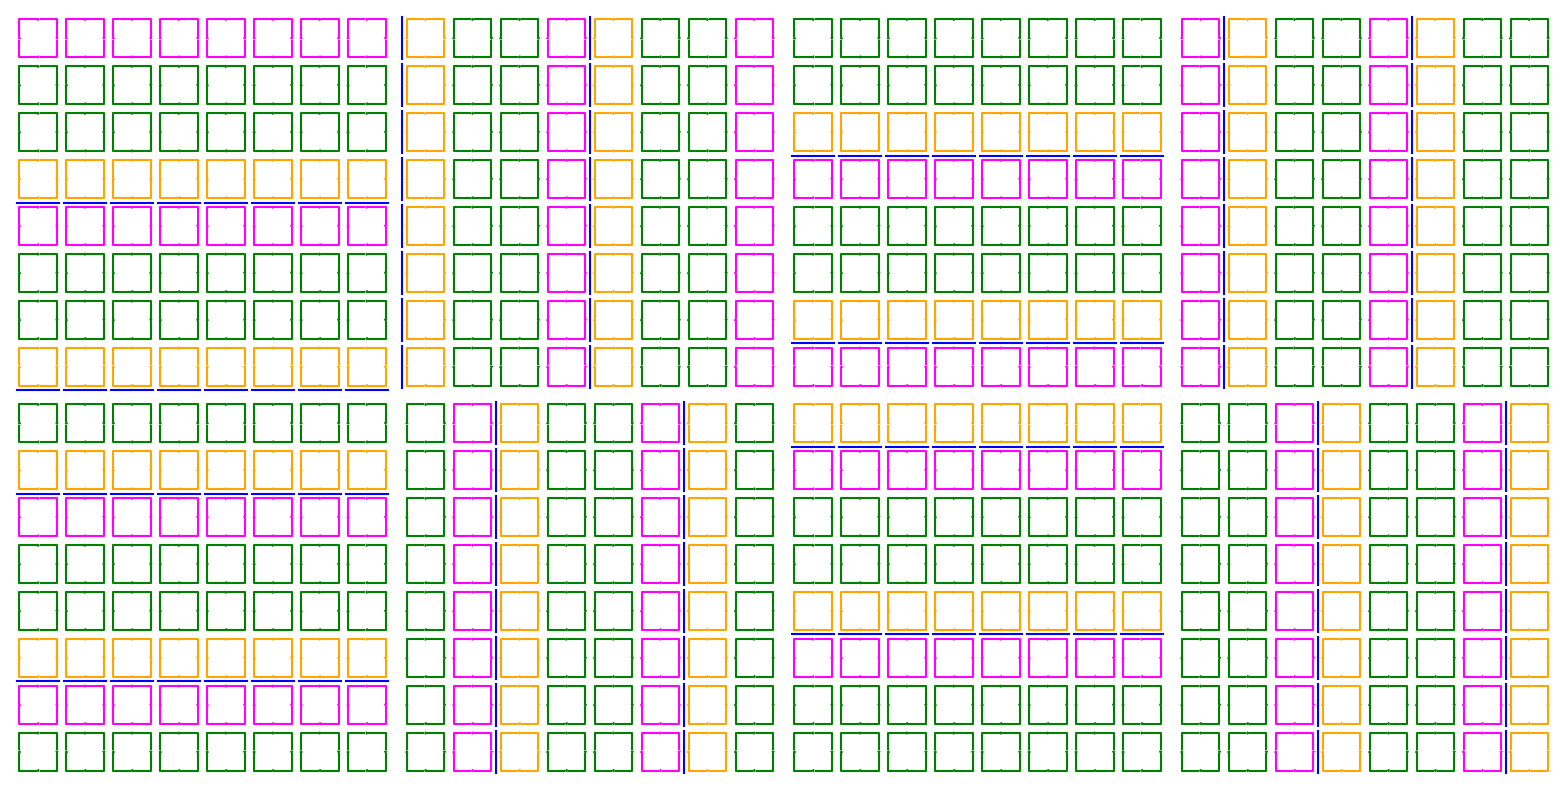

In [70]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
plt.subplots_adjust(hspace=0, wspace=0)
axs = ax.ravel()
for i in range(8):
    plot_plaq_mask(axs[i], masks[i]);

In total, we need eight coupling layers to update every link once. This sequence will be repeated multiple times. Please note that because of those masking patterns, the size of the lattice must be a multiple of four.

### Gauge equivariance -- summary

To summarize the action of a single gauge equivariant coupling layer is as follows:

1. The plaquettes and optionally other loops  are calculated.
2. Plaquettes are partitioned into active, passive and frozen plaquettes. This split will be called masking, as it is usually implemented by masking parts of the lattice.  
3. The active plaquettes are transformed using a kernel $h$ that is a function of the invariants build out of the frozen plaquettes.
4. Active links are updated to reflect the change in active plaquettes.

The above procedure is repeated until all links are updated a sufficient number of times.

From this description,  it follows that to specify a gauge equivariant coupling layer, we need to specify the masking pattern and the plaquettes coupling layer. 

##  Plaquettes coupling layer

In general, kernel $h$ must be a diffeomorphism from the gauge group $G$ onto itself. In case of $U(1)$ those are the diffeomorphism of the circle $\mathbb{S}^1$ onto  itself. In terms of phases $\phi$ the sufficient conditions on $h$ are

\begin{split}
h(0)&=0\\
h(2\pi)&=2\pi\\
\nabla h(\phi) &>0\\
\left.\nabla h(\phi)\right|_{\phi=0}&=\left.\nabla h(\phi)\right|_{\phi=2\pi}
\end{split}

For details see:
Rezende, D. J., Papamakarios, G., Racanière, S., Albergo, M. S., Kanwar, G., Shanahan, P. E., & Cranmer, K. (2020). Normalizing Flows on Tori and Spheres. 37th International Conference on Machine Learning, ICML 2020, PartF16814, 8039–8048. https://doi.org/10.48550/arxiv.2002.02428, [arXiv:2002.02428](https://arxiv.org/abs/2002.02428)

## Non compact projection (NCP) plaquettes coupling

Following [arXiv:2101.08176](https://arxiv.org/abs/2101.08176) by M.S. Albergo et al., from where parts of this code were taken,  we implement  non-compact projection  as the plaquettes coupling layer. 

We first project the angle $\phi\in(0,2\pi)$ onto real line $\mathbb{R}$ using transformation $x(\phi)$ defined as 

$$x(\phi)=\tan\left(\frac{\phi}{2}\right)$$

then we apply  linear transformation 

$$g(x)=e^{s} x$$ 

where $s$ is a  learnable parameter. Finally, we project $x$ back onto $\phi\in(0,2\pi)$. Putting this all together, we obtain for $h$

$$h(\phi|s)=2\arctan\left(e^{s} \tan\left(\frac{\phi}{2}\right)\right)$$

In [71]:
from neumc.nf.ncp import tan_transform

In [72]:
tan_transform(torch.FloatTensor([torch.pi]),s=torch.FloatTensor([0.0]))

tensor([3.1415930])

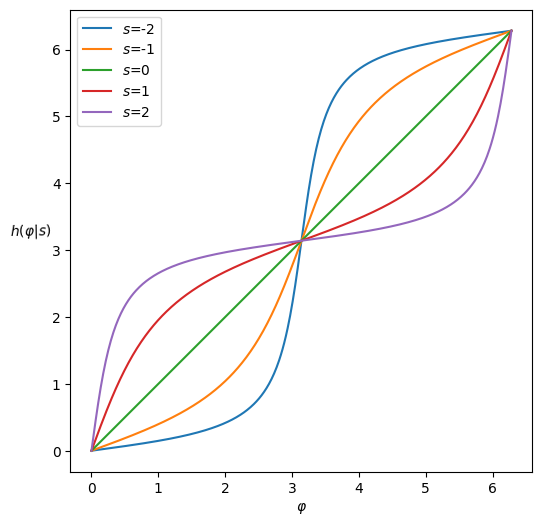

In [73]:
fig, ax = plt.subplots(figsize=(6,6))
ax.set_aspect(1)
ax.set_xlabel(r"$\varphi$")
ylabel = ax.set_ylabel(r"$h(\varphi|s)$", rotation=True, labelpad=15)
phis = torch.linspace(0, 2 * np.pi - 0.00001, 500)
for s in (-2, -1, 0, 1, 2):
    plt.plot(phis, tan_transform(phis, torch.FloatTensor([s])), label=f"$s$={s:.0f}");
ax.legend();
fig.savefig("ncp.pdf")

With such defined $h$ the final transformation is obtained by averaging `n_mixture_components` of such transformations with an additional translation at the end 

$$h(\phi,\vec s|t) =\mod\left(\frac{1}{N_{mix}}\sum_{i=0}^{N_{mix}-1}h(\phi|s_i) +t,2\pi\right)$$

Below, we present an example of such function. Parameter $t$ is set to zero, a non-zero value of this parameter shifts the place where function jumps from zero to $2\pi$.

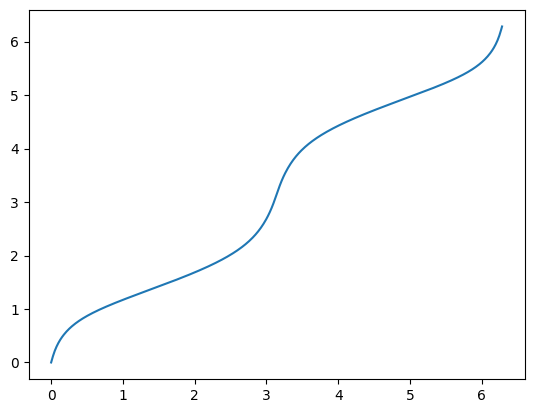

In [74]:
n_mixture_components = 18
s = 8 * torch.rand(size=(n_mixture_components,)) - 4
out = torch.zeros_like(phis)
for i in range(n_mixture_components):
    out += tan_transform(phis, s[i])
out /= n_mixture_components
fig, ax = plt.subplots()
ax.plot(phis, neumc.physics.u1.torch_mod(out));

It is very important to note that we have a different transformation **at each site**, that is $s$ is really a tensor of size $(N_{mix},L,L)$.

In [75]:
prior = neumc.nf.prior.MultivariateUniform(torch.zeros((2, *lattice_shape)),
                                           2 * torch.pi * torch.ones((2, *lattice_shape)), device=torch_device)

For each layer, parameters $\vec s$ and $t$ will be obtained from a convolutional neural network. The general architecture of such networks was described in the $\phi^4$ notebook. In here, we use the network with two input channels and two hidden layers of eight channels each.  The number of output channels is set by the number of mixtures, as we need one channel for each $s_i$ and one for $t$. 

In [76]:
hidden_channels = [16, 16]
kernel_size = 3
n_mixture_components = 18
in_channels = 2
out_channels = n_mixture_components + 1

The number of input channels requires an explanation. We store the link variables $U(0)$ as phases $\phi\in[0,2\pi]$ But in reality  we identify both ends of this interval. This is not respected by our parameterisation, for a neural network input $0$ and $2\pi$ are very different. So instead of using $\phi$ directly we use the tuple $(\cos(\phi), \sin(\phi))$ which is periodic in $\phi$. 

### Masks function

The masks are produced by the <span class="tt">u1_masks</span> function. 

In [77]:
masks = neumc.nf.gauge_masks.u1_masks_gen(lattice_shape=(8, 8), float_dtype=float_dtype, device=torch_device)

This function returns a _generator_ that loops cyclically through all the masking patterns. A t each stage it produces a tuple

In [78]:
mask0 = next(masks)

In [79]:
len(mask0)

2

The first element of the tuple is a links mask indicating which links are active _i.e._ will be changed 

In [80]:
mask0[0]

tensor([[[1., 0., 0., 0., 1., 0., 0., 0.],
         [1., 0., 0., 0., 1., 0., 0., 0.],
         [1., 0., 0., 0., 1., 0., 0., 0.],
         [1., 0., 0., 0., 1., 0., 0., 0.],
         [1., 0., 0., 0., 1., 0., 0., 0.],
         [1., 0., 0., 0., 1., 0., 0., 0.],
         [1., 0., 0., 0., 1., 0., 0., 0.],
         [1., 0., 0., 0., 1., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.]]])

The second element of the tuple is again a tuple or list. The first element of this list is the _plaquette_ mask Which is a dictionary with masks indicating frozen, passive and active plaquettes  as described above.  The remaining elements of this list may contain additional  _loops_ masks. This is described in more detail in the <span class="tt">U1_rs</span> notebook. In our case, we have only plaquette mask

In [81]:
len(mask0[1])

1

In [82]:
mask0[1]

({'frozen': tensor([[0, 1, 1, 0, 0, 1, 1, 0],
          [0, 1, 1, 0, 0, 1, 1, 0],
          [0, 1, 1, 0, 0, 1, 1, 0],
          [0, 1, 1, 0, 0, 1, 1, 0],
          [0, 1, 1, 0, 0, 1, 1, 0],
          [0, 1, 1, 0, 0, 1, 1, 0],
          [0, 1, 1, 0, 0, 1, 1, 0],
          [0, 1, 1, 0, 0, 1, 1, 0]], dtype=torch.uint8),
  'active': tensor([[1, 0, 0, 0, 1, 0, 0, 0],
          [1, 0, 0, 0, 1, 0, 0, 0],
          [1, 0, 0, 0, 1, 0, 0, 0],
          [1, 0, 0, 0, 1, 0, 0, 0],
          [1, 0, 0, 0, 1, 0, 0, 0],
          [1, 0, 0, 0, 1, 0, 0, 0],
          [1, 0, 0, 0, 1, 0, 0, 0],
          [1, 0, 0, 0, 1, 0, 0, 0]], dtype=torch.uint8),
  'passive': tensor([[0, 0, 0, 1, 0, 0, 0, 1],
          [0, 0, 0, 1, 0, 0, 0, 1],
          [0, 0, 0, 1, 0, 0, 0, 1],
          [0, 0, 0, 1, 0, 0, 0, 1],
          [0, 0, 0, 1, 0, 0, 0, 1],
          [0, 0, 0, 1, 0, 0, 0, 1],
          [0, 0, 0, 1, 0, 0, 0, 1],
          [0, 0, 0, 1, 0, 0, 0, 1]], dtype=torch.uint8)},)

Because we have already called next on the masks' generator, we have to regenerate it

In [83]:
masks = neumc.nf.gauge_masks.u1_masks_gen(lattice_shape=lattice_shape, float_dtype=float_dtype, device=torch_device)

As stated above, the parameters of the plaquette  coupling layer are given by an output of the neural network, which takes as an input the frozen plaquettes.  Function below is an auxiliary function that constructs the neural network, which in turn is used for constructing  the plaquette coupling layer using the given plaquette mask. 

In [84]:
def make_plaq_coupling(mask):
    net = neumc.nf.nn.make_conv_net(in_channels=in_channels,
                                    out_channels=out_channels,
                                    hidden_channels=hidden_channels,
                                    kernel_size=kernel_size,
                                    use_final_tanh=False,
                                    dilation=[1,2,3])
    net.to(torch_device)
    return neumc.nf.ncp.NCPPlaqCouplingLayer(net, mask=mask).to(torch_device)

The plaquettes coupling layer transform the plaquettes but finally we need to transform links. That is done by the <span class="tt">GenericGaugeEquivCouplingLayer</span> class that is independent of the plaquettes coupling layer. Finally,  we construct a number of such layers, changing masks at each step 

In [85]:
from neumc.nf.flow_abc import TransformationSequence

In [86]:
n_layers = 16
layers = []
for i in range(n_layers):
    link_mask, plaq_mask = next(masks)
    plaq_coupling = make_plaq_coupling(plaq_mask)
    link_coupling = neumc.nf.u1_equiv.U1GaugeEquivCouplingLayer(
        loops_function=None,
        active_links_mask=link_mask,
        plaq_coupling=plaq_coupling,
    )

    layers.append(link_coupling)
layers = TransformationSequence(layers).to(torch_device)

In [87]:
z = prior.sample_n(256)

In [88]:
model = {
    'prior': prior,
    'layers': layers
}

In [89]:
# Training
base_lr = .001
lambda_2 = 1e-5
optimizer = torch.optim.Adam(model['layers'].parameters(), lr=base_lr, weight_decay=lambda_2)

N_era = 6
N_epoch = 20 
print_freq = N_epoch  # epochs
plot_freq = 5  # epochs
batch_size = 2 ** 10

history = {
    'dkl': [],
    'std_dkl': [],
    'loss': [],
    'ess': []
}

In [90]:
#==================
#SAVING CNN WEIGHTS
#==================

MODEL_WEIGHTS_PATH = "weights.pt"

# Check if weights file exists and load them
if os.path.exists(MODEL_WEIGHTS_PATH):
    print(f"Loading existing weights from {MODEL_WEIGHTS_PATH}")
    state_dict = torch.load(MODEL_WEIGHTS_PATH)
    model['layers'].load_state_dict(state_dict)
    print("✓ Weights loaded successfully!")
else:
    print(f"No existing weights found at {MODEL_WEIGHTS_PATH}")
    print("Starting training with random initialization")


No existing weights found at weights.pt
Starting training with random initialization


The NCP transformation is not easily invertible (it requires solving an equation) because of that it, it is not suited to be used with the REINFORCE and path_gradient gradient estimators. 

In [91]:
from neumc.training.gradient_estimator import RTEstimator
from neumc.training.gradient_estimator import REINFORCEEstimator

gradient_estimator = RTEstimator(prior, layers, u1_action, False)
#gradient_estimator = REINFORCEEstimator(prior, layers, u1_action, False)

In [92]:
from live_plot import init_live_plot, update_plots
import time

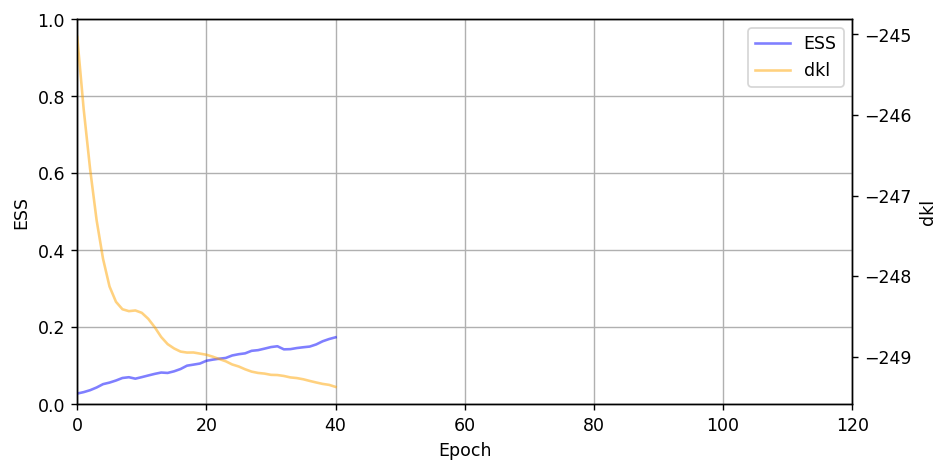

Era   0 epoch   19 ellapsed time 53.9
dkl -246.01
std_dkl 2.72539
loss -246.01
ess 0.0438722
Era   1 epoch   19 ellapsed time 94.3
dkl -249.026
std_dkl 1.61209
loss -249.026
ess 0.118568


KeyboardInterrupt: 

In [93]:
%%time
[plt.close(plt.figure(fignum)) for fignum in plt.get_fignums()]  # close all existing figures
live_plot = init_live_plot(N_era, N_epoch, metric='dkl')
start_time = time.time()

for era in range(N_era):
    for epoch in range(N_epoch):
        optimizer.zero_grad()
        loss_, logq, logp = gradient_estimator.step(batch_size)
        optimizer.step()
        m = {
                "loss": loss_.cpu().numpy().item(),
                "ess": neumc.utils.ess(logp, logq).cpu().numpy().item(),
                "dkl": neumc.utils.dkl(logp, logq).cpu().numpy().item(),
                "std_dkl": (logp - logq).std().cpu().numpy().item(),
            }
        neumc.utils.metrics.add_metrics(history, m)

        if (epoch + 1) % print_freq == 0:
            avg = neumc.utils.metrics.average_metrics(history, N_epoch, history.keys())
            ellapsed_time = time.time() - start_time
            print(f"Era {era:3d} epoch {epoch:4d} ellapsed time {ellapsed_time:.1f}")
            neumc.utils.metrics.print_dict(avg)

        if (epoch + 1) % plot_freq == 0:
            update_plots(history, **live_plot)


In [ ]:
# Save model weights after training
print(f"\nSaving model weights to {MODEL_WEIGHTS_PATH}")
torch.save(model['layers'].state_dict(), MODEL_WEIGHTS_PATH)
print("✓ Model weights saved successfully!")
print(f"File size: {os.path.getsize(MODEL_WEIGHTS_PATH) / (1024**2):.2f} MB")


## Sampling

Please refer to the $\phi^4$ notebook for the detailed explanation of concepts and quantities used in the  following.  

The sampling function generates n_samples of configurations from the distribution $q$. The sampling is done in batches because the sample can be too big to fit on the GPU.

In [ ]:
%%time
u, lq = neumc.nf.flow.sample(n_samples=2 ** 10, batch_size=2 ** 10, prior=prior, layers=layers)

Calculating action, that is equal to $-\log p$, on the sample is also done in batches, for the same reason as above|

In [ ]:
lp = -neumc.utils.batch_function.batch_action(u, batch_size=1024, action=u1_action, device=torch_device)

The trained model has a decent effective sample size

In [ ]:
neumc.utils.ess(lp, lq)

In [ ]:
fit = linregress(lq, lp)
print(f"log P = {fit.slope:.3f} log q + {fit.intercept:.3f}")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1);
ax.set_xlabel(r"$\log q$");
ax.set_ylabel(r"$\log P$")
plt.title(r"plot for $\beta$ = " + f"{beta}")
lqs = np.linspace(lq.min(), lq.max(), 100);
ax.scatter(lq, lp, s=5, alpha=0.25);
ax.plot(lqs, lqs * fit.slope + fit.intercept, color='red', zorder=10);
ax.text(0.15, .85, f"$\\log P = {fit.slope:.3}\\log q+{fit.intercept:.3f}$", transform=ax.transAxes);

## Free energy

As described in the $\phi^4$ notebook, the variational free energy is given by the $D_{KL}$

In [ ]:
F_q = neumc.utils.dkl(lp, lq)
print(f"F_q = {F_q:.3f} F_q-F_exact = {F_q - F_exact:.4f}")

Please note that the relative error is about 1&permil;




In [ ]:
print(f"{(F_q - F_exact) / np.abs(F_exact):.5f}")

The statistical error can be calculated using bootstrap

In [ ]:
from neumc.utils.stats_utils import torch_bootstrap, torch_bootstrapf

In [ ]:
lw = lp - lq

In [ ]:
%%time
F_q, F_q_std = torch_bootstrap(-lw, n_samples=100, binsize=1)

In [ ]:
print(f"F_q = {F_q:.4f}+/-{F_q_std:.4f}")

The statistical error is much less than the difference, indicating that the variational estimate is biased. As explained in the$\phi^4$ notebook, we can use the _importance  weights_ 

$$w(u)=\frac{p(u)}{q(u)}$$

to obtain an (almost)unbiased estimate

In [ ]:
%%time
F_nis, F_nis_std = torch_bootstrapf(lambda x: -(torch.special.logsumexp(x, 0) - np.log(len(x))), lw,
                                    n_samples=100,
                                    binsize=1)

In [ ]:
print(f"F_NIS = {F_nis:.3f}+/-{F_nis_std:.4f} F_NIS-F_exact = {F_nis - F_exact:.4f}")

## Neural Markov Chain Monte-Carlo

In [ ]:
from neumc.mc import metropolize

In [ ]:
u_p, s_p, s_q, accepted = metropolize(u, lq, lp)

In [ ]:
print("Accept rate:", grab(accepted).mean())

In [ ]:
Q = grab(u1.topo_charge(u_p))
plt.figure(figsize=(5, 3.5), dpi=125)
plt.plot(Q)
plt.xlabel(r'$t_{MC}$')
plt.ylabel(r'topological charge $Q$')
plt.title(r"plot for $\beta$ = " + f"{beta}")
plt.show()

In [ ]:
from neumc.utils.stats_utils import bootstrap

In [ ]:
X_mean, X_err = bootstrap(Q ** 2, n_samples=100, binsize=16)
print(f'Topological susceptibility = {X_mean:.2f} +/- {X_err:.2f}')